# Несколько слов про tool-блоки в домашках

Классного датасаентиста помимо всего прочего отличает его "портфель" - набор готового кода на все случаи жизни,
    который он носит с собой где бы он ни работал и какую бы домашку не делал. Во время различных профессиональных занятий
    всегда хорошо сохранить функцию, которая помогла вам сейчас решить конкретную задачу себе "в папочку", чтобы столкнувшись
    с такой / похожей задачей дальше, иметь под рукой oneliner, который сделает все так, как вам хочется.
    
Время от времени в ваших домашках будут появляться tool-блоки, в которых мы будем просить вас написать что-нибудь, что вам
    пригодится в дальнейшем, а также закрепляет пройденный материал.
    Настоятельно рекомендуем завести себе хранилище, куда вы будете складывать функции из домашек,
    а также те, которые напишете сами и сочтете достойными.

В дальнейшем вы сможете импортировать ваши функции в любой проект, например, так:

`import sys` <br>
`sys.path.append('/*SOME_PATH*/my_code/my_utils')` <br>
`from utils.plot import plot_denisty` <br>

<br>    
Скорее всего, со временем вы захотите дополнить / исправить / переделать под себя эти функции, и это правильно,
    однако в домашках нужно сделать ровно то, что написано в задании - ни больше, ни меньше. Все остальное - уже самостоятельно.
    Можно воспринимать функции из домашек как шаблоны, вдохновляющие вас на дальнейшее творчество.
    Чтобы вы в будущем могли разобраться, что происходит у вас в коде (а тем более - проверяющие), мы будем просить вас писать
    комментарии к вашему коду и докстринги (пример ниже). Это несложная и очень полезная привычка, которая не раз выручит вас.

Условия проверки tool-блоков:
- Если какая-то часть задания не реализована или вы сделали что-то запрещенное, вы получаете 0 баллов за задачу
- Если сделано все, что описано в задании и не сделано ничего запрещенного, есть docstring и комментарии к коду,
    вы получаете полный балл за задачу
- После получения полного балла, могут быть вычтены баллы за любого рода неадекватность. Размер штрафа субъективен
    и коррелирует с масштабом неадекватности - на что-то можно закрыть глаза, на что-то не получится.
- Вспомогательные принты и любые следы тестирования - неадекватность
- Неадекватностью может являться кривое выполнение пункта задания, однако если мы посчитаем пункт кривым,
    это не значит, что у вас 0 за задачу. Не сделать и сделать неправильно - разные вещи
- Некоторые советы и намеки на то, что считается адекватным для конкретной задачи, можно будет найти в задании :)

В данной домашке вам предлагается реализовать две функции на датасете титаник, немного измененном следующим образом:

In [1]:
from typing import Optional, List

import pandas as pd
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic/train.csv")
df.Embarked = df.Embarked.replace("Q", "")
df.PassengerId = df.PassengerId.astype("string")

## tool: информация о колонках датафрейма (4 балла)

#### чтобы получить полный балл, нужно прикрепить ваш правильно работающий пример в отдельном окошке

Напишите функцию `get_df_info`, которая будет выводить информацию о колонках входного датафрейма. Функция должна возвращать датафрейм следующего формата:

- индекс - все колонки входного датафрейма


- в колонках результирующего датафрейма содержится следующая информация (см. пример ниже):
    - тип данных
        - используйте `df.col.dtype.name`, это стабильнее, чем `df.col.dtype`
    - количество уникальных элементов
        - включая наны
    - доля нанов в колонке
    - доля нулей в колонке
    - доля пустых строк в колонке
    - доля самого частовстречаемого элемента в колонке + сам этот элемент (aka `vc_max`)
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        - если таких несколько - можно брать любой
        
    - два разных примера содержимого колонки
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        
    - `trash_score` колонки: max([суммарная доля нанов, нулей и пустых строк], [`vc_max`.доля if `vc_max`.доля > thr else 0])
        - thr нужно принимать в качестве аргумента функции, поставив по умолчанию что-то адекватное
      
      
- про адекватность
    - нужно сделать так, чтобы как можно больше выводимой вами информации было понятно глазу без доп. усилий
    - округляйте до трех знаков доли
    - выводите чистый 0 спецсимволом, чтобы не путать с округлившимся 0.00001 (напр. '' или -1)
    - если нужно, выводите числа в виде строк
    - убедитесь, что в случае когда двух примеров не набирается, вы можете отличить информацию "примера нет" от пустой строки
    - можете использовать доп. символы, чтобы отличать колонки быстрее, где нужно (напр. 'z:', 'n:', 'e:')
    - обрабатывайте любые другие возникающие неадекватные ситуации и приводите их в адекватный вид :)
    
    
- запрещено: итерироваться по строкам входного датафрейма в любом виде (по колонкам можно)

In [3]:
def join(elems: list, delimiter: str = ", "):
    result = ""
    for i, elem in enumerate(elems):
        result += str(elem)
        if i < len(elems) - 1:
            result += delimiter

    return result


def get_df_info(
    df: pd.DataFrame, trash_threshold: float = 0.2, *args, **kwargs
) -> pd.DataFrame:
    """
    Finds general info on given DataFrame

    Args:
        df: pd.DataFrame - DataFrame to get info about
        trash_threshold: float - Threshold for trash score. Resulting trash score
            is calculated using formula: trash_score = max(nan_fraction, null_fraction, empty_string_fraction),
            if trash_score > trash_threshold, 0 otherwise

    Returns:
        pd.DataFrame with info about given DataFrame
    """

    dtypes = df.dtypes.map(lambda x: x.name)
    nunique = df.nunique()
    nan_fractions = df.isna().mean().round(3).tolist()
    null_fractions = (df == 0).mean().round(3).tolist()
    empty_string_fractions = (df == "").mean().round(3).tolist()
    most_common_elem = [df[col].mode()[0] for col in df.columns]

    most_common_elem_fraction = [
        (df[col] == most_common_elem[i]).mean().round(3)
        for i, col in enumerate(df.columns)
    ]

    two_examples = [
        # purge NaNs to select non-NaN samples
        join(df[~df[col].isna()][col].sample(n=2).tolist())
        # if can't choose two samples, put "no examples"
        if len(df[~df[col].isna()][col]) >= 2
        else "no examples"
        for col in df.columns
    ]

    trash_scores = list(
        map(
            # trash score is max from nan_fraction, null_fraction, empty_string_fraction
            # if trash_score > trash_threshold, 0 otherwise
            lambda x, y, z: max(x, y, z) if max(x, y, z) > trash_threshold else 0.0,
            nan_fractions,
            null_fractions,
            empty_string_fractions,
        )
    )

    return pd.DataFrame(
        {
            "dtype": dtypes,
            "nunique": nunique,
            "nan_fraction": nan_fractions,
            "null_fraction": null_fractions,
            "empty_string_fraction": empty_string_fractions,
            "most_common_elem": most_common_elem,
            "most_common_elem_fraction": most_common_elem_fraction,
            "two_examples": two_examples,
            "trash_score": trash_scores,
        }
    ).replace(0, "-1")  # replace zeros with special symbol "-1"

In [4]:
# ваш пример
get_df_info(df)

,dtype,nunique,nan_fraction,null_fraction,empty_string_fraction,most_common_elem,most_common_elem_fraction,two_examples,trash_score
PassengerId,string,891,-1,-1,-1,1,0.001,"172, 295",-1
Survived,int64,2,-1,0.616,-1,-1,0.616,"0, 0",0.616
Pclass,int64,3,-1,-1,-1,3,0.551,"3, 1",-1
Name,object,891,-1,-1,-1,"Abbing, Mr. Anthony",0.001,"Peter, Miss. Anna, Pengelly, Mr. Frederick Wil...",-1
Sex,object,2,-1,-1,-1,male,0.648,"female, female",-1
Age,float64,88,0.199,-1,-1,24.0,0.034,"23.0, 36.0",-1
SibSp,int64,7,-1,0.682,-1,-1,0.682,"0, 0",0.682
Parch,int64,7,-1,0.761,-1,-1,0.761,"0, 0",0.761
Ticket,object,681,-1,-1,-1,1601,0.008,"12749, 349227",-1
Fare,float64,248,-1,0.017,-1,8.05,0.048,"7.8958, 10.5",-1


In [ ]:
# Это пример, не запускайте эту ячейку

# WARNING: пример не обязан соблюдать все пункты задания, но вы обязаны :)

get_df_info(df)

,dtype,nunique,example_1,example_2,zero,nan,empty_str,vc_max,trash_score
,,,,,,,,,
Cabin,object,147,C148,B42,-1,n: 0.771,-1,"(0.02, G6)",0.771
Parch,int64,7,6,4,z: 0.761,-1,-1,"(0.761, 0)",0.761
SibSp,int64,7,8,5,z: 0.682,-1,-1,"(0.682, 0)",0.682
Survived,int64,2,1,0,z: 0.616,-1,-1,"(0.616, 0)",0.616
Age,float64,88,74.0,34.5,-1,n: 0.199,-1,"(0.042, 24.0)",0.199
Embarked,object,3,'',C,-1,n: 0.002,e: 0.086,"(0.724, S)",0.089
Fare,float64,248,10.5167,9.8458,z: 0.017,-1,-1,"(0.048, 8.05)",0.017
Ticket,object,681,370376,111369,-1,-1,-1,"(0.008, 347082)",-1
Sex,object,2,female,male,-1,-1,-1,"(0.648, male)",-1


## tool: распределения признаков (6 баллов)

#### чтобы получить полный балл, нужно прикрепить ваш правильно работающий пример в отдельном окошке и ответить на вопрос в конце

**!** Обновите matplotlib, seaborn до последней версии

Нужно реализовать рисовалку распределения колонок датафрейма через функцию или через класс, как вам удобней.
    Отрисовываемые колонки принимаются на вход. Далее вы для каждой такой колонки создаете `fig, ax` и отрисовываете туда то,
    что описано ниже в задании. Также, на вход принимается hue-колонка (см. семинар), по которой бьется раскраска.

- для числовых колонок
    - sns.histplot
        - предобработка данных: принимайте на вход флажок `drop_zero`. Если он True, выкиньте все нули прежде чем рисовать
        - количество бинов остается за вами
        - используйте аргументы `multiple='stack'`, `element='step'` (самый быстрый), `stat='count'`,
            `alpha=0.8` (чтобы подогнать цвет гистограммы под остальные цвета, без этого будет слишком яркий график)
        
    - sns.boxenplot + sns.stripplot
        - предобработка данных: если `drop_zero`, рисуем оба графика без нулей
        - в boxenplot используйте `showfliers=False`, выбросы будут подсвечиваться stripplot'ом
        - в stripplot не нужно рисовать все точки, нужно засэмплировать немного (напр. 200)
        
    - special (0, np.nan)
        - это будет sns.barplot, показывающий распределение по спец. значениям - нулям и нанам
        - предобработка данных: посчитайте для каждого значения колонки `hue` (см. groupby) долю нанов и нулей
            (независимо от `drop_zero`), оберните в датафрейм и отрисуйте с помощью sns.barplot
        - вместо чистого нуля используйте что-то отрицательное (напр. -0.1 * [значение самого высокого бина])
        - используйте у barplot аргумент `edgecolor='black'`
        - добавьте `ax.axhline(0, color='black', ls='--')` на этот же ax, чтобы четко выделить 0
        - добавьте горизонтальную решетку `ax.grid(True, axis='y')`
        
    
- для категориальных колонок
    - категориальными считаем все (числовые / нечисловые) колонки c количеством уникальных
        значений меньше `max_cat_thr`: принимаем на вход (напр. 20)
        
    - sns.countplot + обработка пустых строк, нанов
        - предобработка данных: замените все наны и пустые строки на понятные вам спецстроки для наглядности (см. пример)
        - используйте `stat='count'`, `edgecolor='black'`
        - добавьте горизонтальную решетку
        - поверните выводимые значения на оси X на 90 градусов `ax.tick_params('x', rotation=90)`
        
        
- общее:
    - убедитесь, что не рисуете колонку, которую передаете в hue, а также колонки, которые не попали ни в числовые,
        ни в категориальные
    
    - настройте `ax.set_title`, `fig.suptitle` - пусть они помогают вам и нам быстро разобраться, что на графике.
        Не нужно подписывать, что на графике histplot или что-то подобное, лучше подпишите какое-нибудь уточнение к графику,
        например, что ящики построены без учета выбросов. Однако, не нужно плодить лишнего.
    
    - уберите все ненужные `ax.set_xlabel`, `ax.set_ylabel`
    
    - пусть на каждую колонку у вас будет по одной легенде на любом из графиков
    
    - настройте у графиков аргумент `hue_order`, чтобы заранее зафиксировать порядок раскраски.
        Например, если ваша hue-колонка Survived, то `hue_order=[0, 1]` зафиксирует, что у вас все что относится к значению 0
        всегда покрасится в первый цвет, а к 1 - во второй. Если вы не будете так делать, вам не всегда гарантируется ожидаемая
        покраска.
    
    - настройте достаточно крупный размер шрифта у всего, у чего можно - аргумент `fontsize`,
        но `ax.tick_params(..., labelsize=)` (напр. 15). Заметка: если создавать легенду через ax.legend(...), задать ей размер
        шрифта можно с помощью аргумента `fontsize`. Но если делать автолегенду в сиборновских функциях (аргумент legend), то
        поменять ей размер шрифта уже очень сложно. Выход - заранее задать в матплотлибе размер шрифта легенды по умолчанию на
        достаточно крупный (код ниже).

    - НЕ объединяйте пустые строки, наны, и т.п. в один "мусорный" бин. Зачастую спецзначения - самая ценная информация по колонке,
        которую никак нельзя терять таким объединением.
        
        
- про адекватность: ниже дан пример того, что у вас может получиться. Там не везде настроен размер шрифтов и не везде интуитивно
    вам понятные titles, но в остальном - пойдет. Главное - чтобы все было хорошо видно и не было лишнего.
    
    
- на будущее: пытаясь применить эту рисовалку на других датасетах, вы столкнетесь с множеством проблем, поскольку задание
    сформулировано только для титаника, и чтобы не переусложнять, не включает в себя разные нюансы.
    Пусть вас это не пугает - переписывайте, добавляйте, исправляйте, все получится! Иметь корректно работающую на любом
    датасете рисовалку очень полезно :)
    

In [5]:
mpl.rcParams["legend.title_fontsize"] = 13
mpl.rcParams["legend.fontsize"] = 13

In [6]:
def plot_density(
    df: pd.DataFrame,
    hue: str,
    cols: Optional[List[str]] = None,
    drop_zeros: bool = False,
    max_cat_thr: int = 10,
) -> None:
    """
    Draws a distribution for each column in `cols` with respect to column `hue`

    Args:
        df: pd.DataFrame
        hue: str Column to use for hue
        cols: List[str] Columns to plot. If None, then all columns df.columns, defaults to None
        drop_zeros: bool Drop rows with all zeros, defaults to False
        max_cat_thr: int Threshold for number of unique entries to consider column categorical

    Returns:
        None
    """
    if cols is None:
        cols = df.columns

    for col in cols:
        # check if column exists
        if col not in df.columns:
            raise ValueError(f"Column {col} not found in df")

        # set fixed hue order to share among all plots
        hue_order = df[hue].unique().tolist()

        # numerical cols must have numerical dtype and have divergent set of unique values
        numerical = (
            pd.api.types.is_numeric_dtype(df[col].dtype)
            and df[col].nunique() > max_cat_thr
        )

        # categorical cols are any columns with limited set of values
        categorical = df[col].nunique() <= max_cat_thr

        if numerical:
            fig, ax = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))

            # for all of the following plots define suitable indexes
            # based on drop_zeros parameter
            index = df.index
            if drop_zeros:
                index = df[df[col] != 0].index

            sns.histplot(
                df.loc[index],
                x=col,
                hue=hue,
                ax=ax[0],
                bins=20,
                multiple="stack",
                stat="count",
                element="step",
                alpha=0.8,
                hue_order=hue_order,
            )
            ax[0].set_title(f"Distribution of {col} vs {hue}")
            ax[0].yaxis.grid(True)
            ax[0].legend().remove()

            sns.boxenplot(
                df.loc[index],
                x=col,
                hue=hue,
                ax=ax[1],
                showfliers=False,
                hue_order=hue_order,
                edgecolor="black",
            )
            ax[1].set_title(f"Value density for {col} vs {hue} (no outliers)")
            ax[1].xaxis.grid(True)
            ax[1].legend().remove()

            sample_index = df.loc[index].sample(n=min(200, len(df.loc[index]))).index
            sns.stripplot(
                df.loc[sample_index],
                x=col,
                hue=hue,
                ax=ax[2],
                alpha=0.8,
                hue_order=hue_order,
            )
            ax[2].set_title(f"200 samples for {col} vs {hue}")
            ax[2].xaxis.grid(True)
            ax[2].legend().remove()

            # for each value of hue calculate number of zeros, NaNs and other values
            hue_groups = df.groupby(hue)
            bar_data = []

            for name, group in hue_groups:
                zero_count = (group[col] == 0).sum()
                nan_count = group[col].isna().sum()
                non_zero_count = group[col].notna().sum() - zero_count

                # Only add categories that exist for the hue group for space economy
                if zero_count > 0:
                    bar_data.append([name, "Zeros", zero_count])
                if nan_count > 0:
                    bar_data.append([name, "NaNs", nan_count])
                if non_zero_count > 0:
                    bar_data.append([name, "Regular values", non_zero_count])

            bar_df = pd.DataFrame(bar_data, columns=[hue, "Category", "Count"])

            sns.barplot(
                data=bar_df,
                x="Category",
                y="Count",
                hue=hue,
                ax=ax[3],
                edgecolor="black",
            )
            ax[3].set_title(f"Distribution of Zeros, NaNs, and other in {col}")
            ax[3].yaxis.grid(True)

            fig.suptitle(f"Distribution of {col}")
            plt.tight_layout()
            plt.show()

        if categorical:
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 4))

            sns.countplot(
                # Replace NaN values and empty strings with special symbols for readability
                df.fillna("<NAN>").replace("", "<EMPTY>"),
                x=col,
                hue=hue,
                ax=ax,
                stat="count",
                edgecolor="black",
                hue_order=hue_order,
            )

            ax.set_title(f"Value counts for {col} vs {hue}")
            ax.yaxis.grid(True)
            ax.tick_params(labelsize=8)

            fig.suptitle(f"Distribution of {col}")

            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()

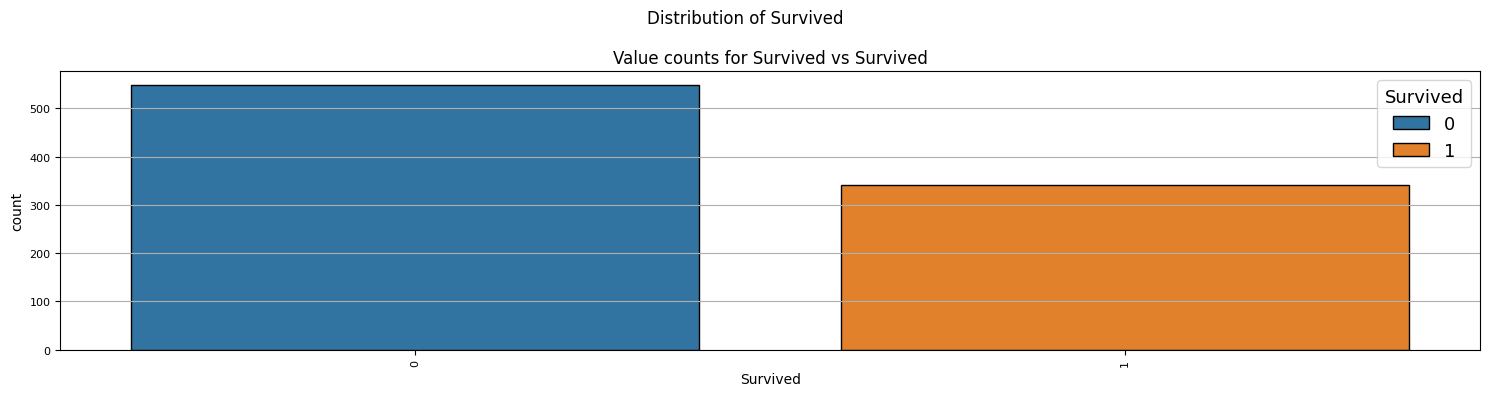

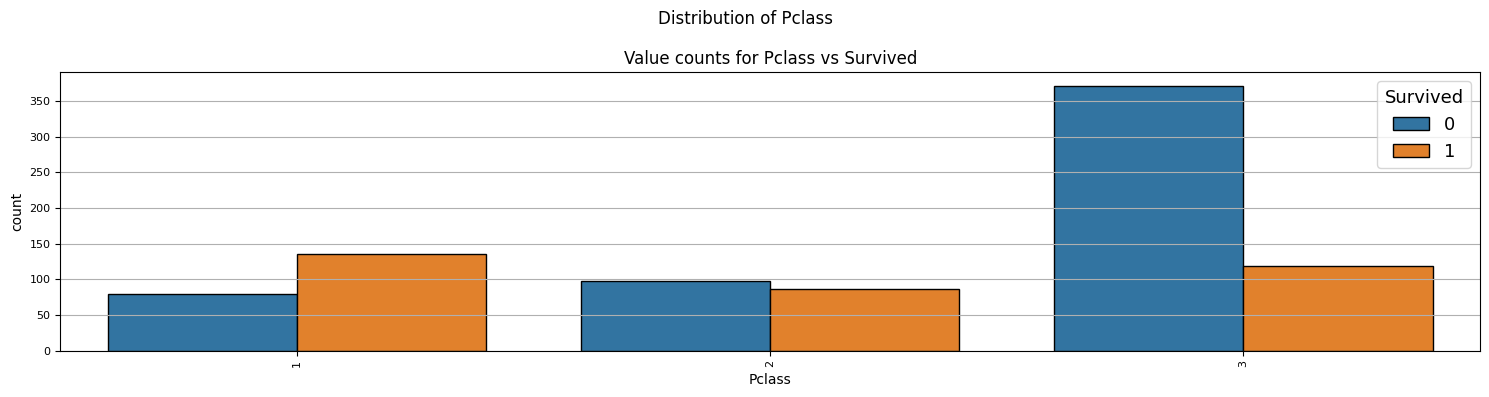

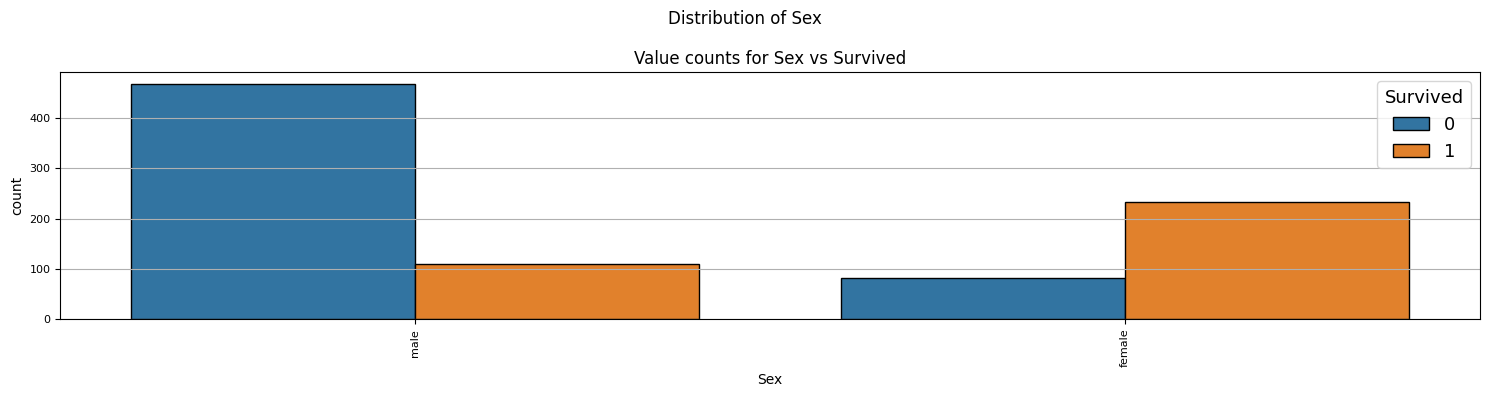

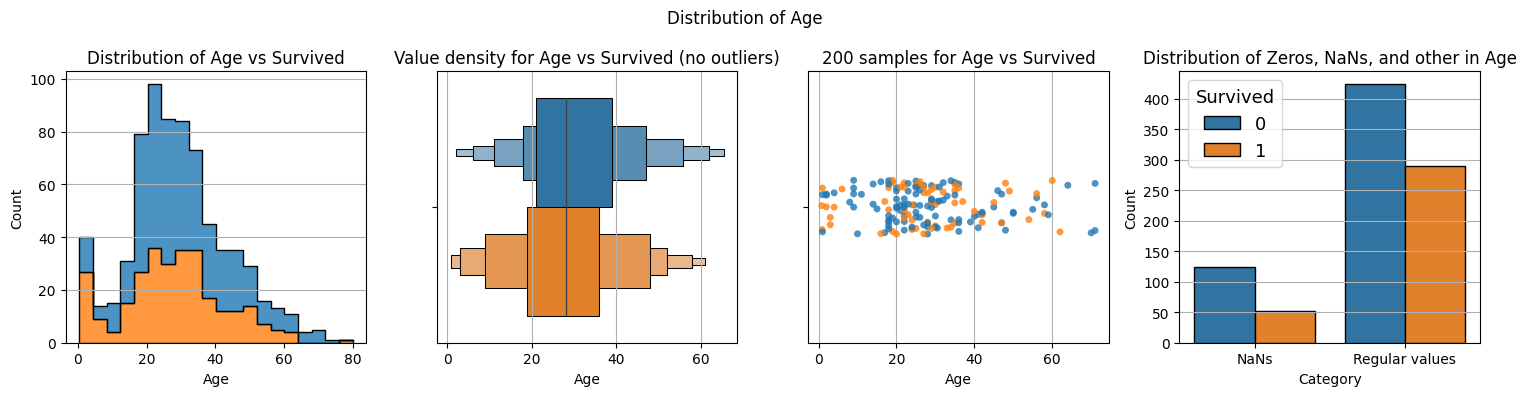

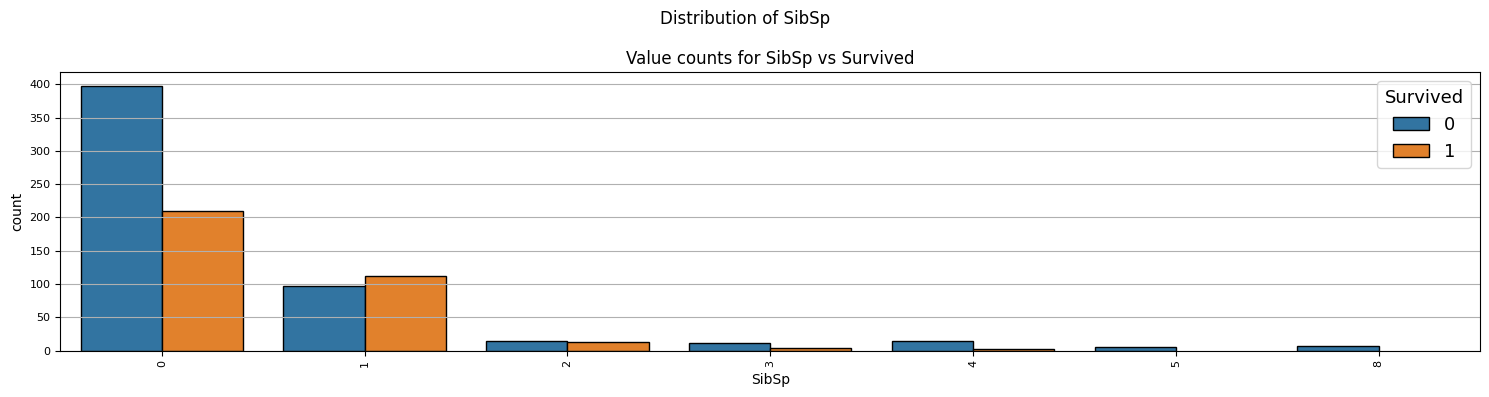

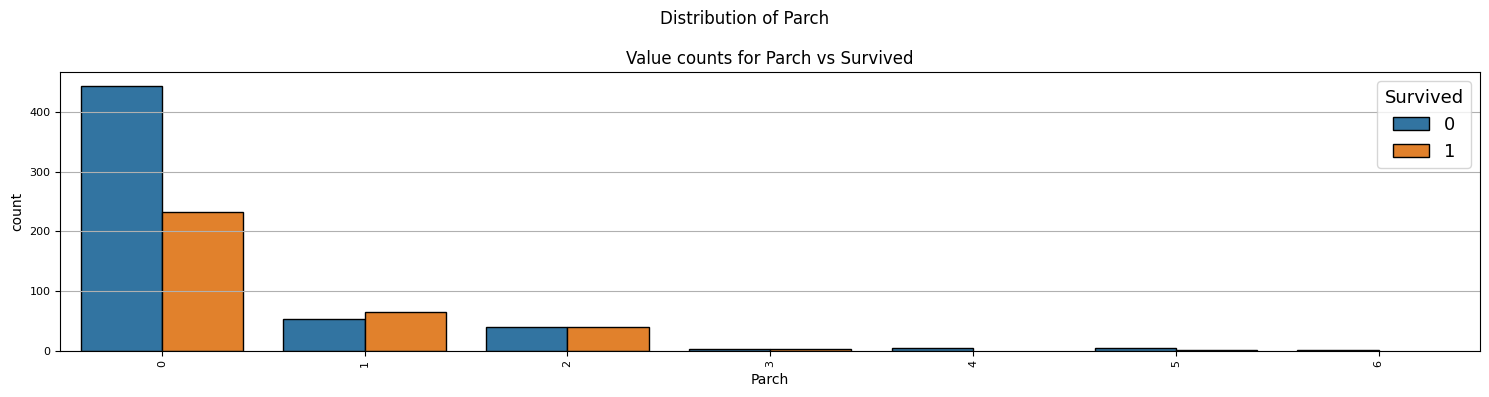

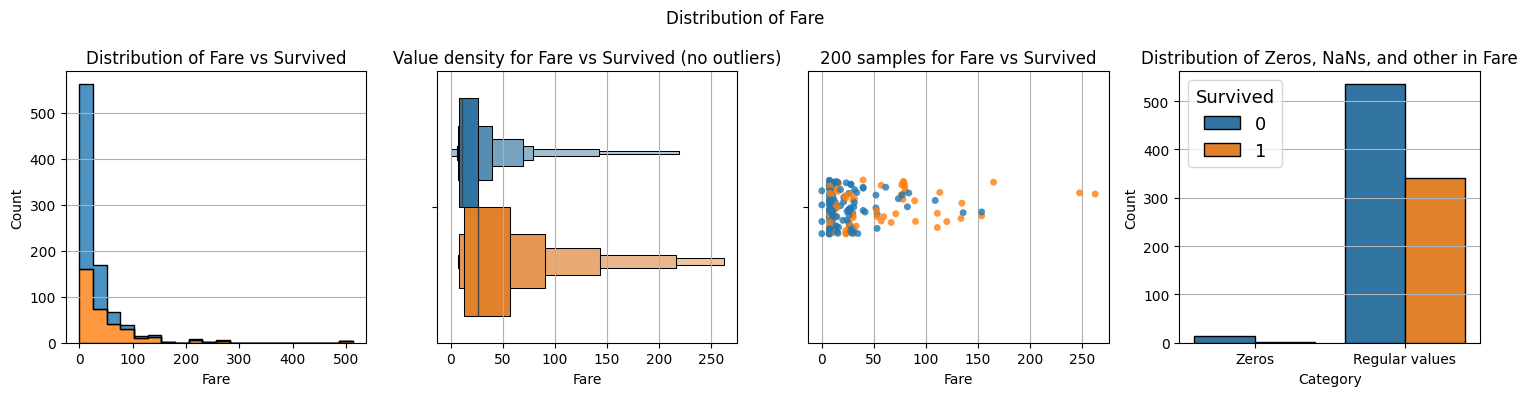

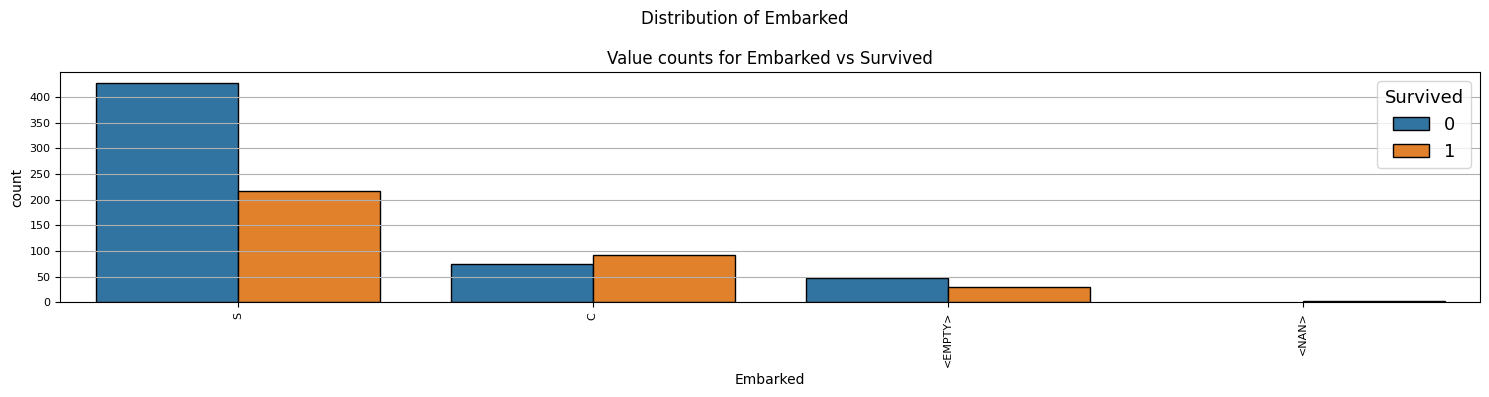

In [7]:
# ваш пример
plot_density(df, hue="Survived", cols=df.columns)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
################################################################################


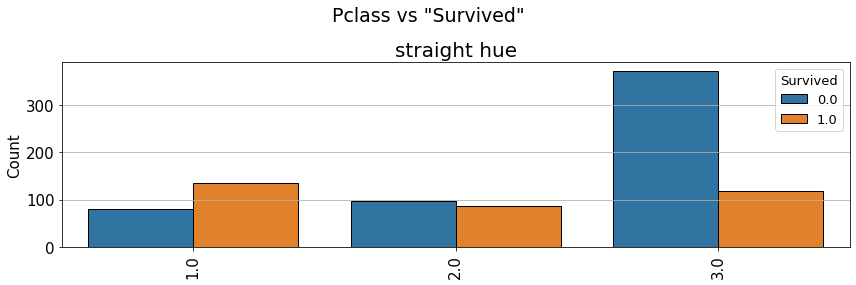

################################################################################


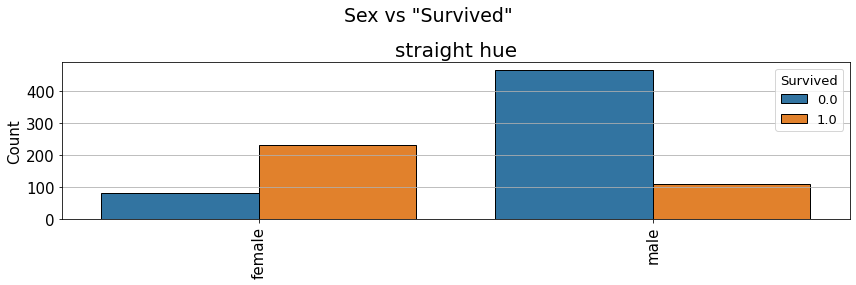

################################################################################


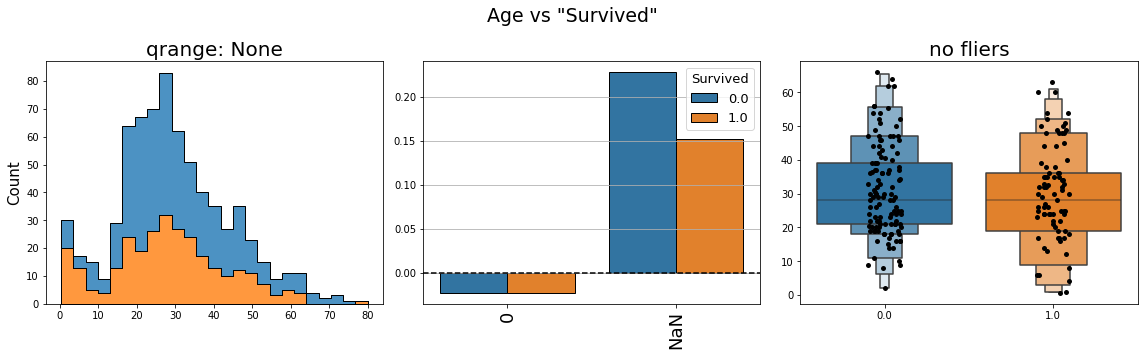

################################################################################


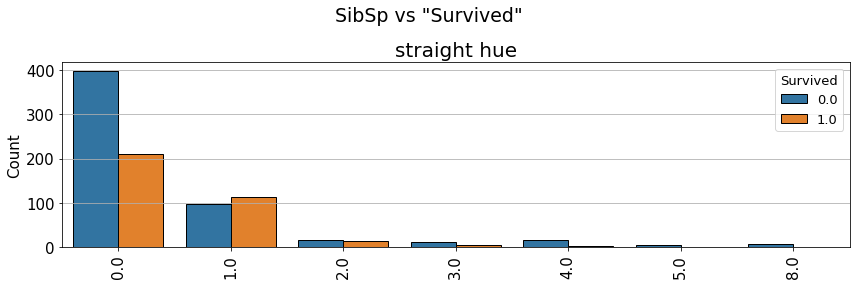

################################################################################


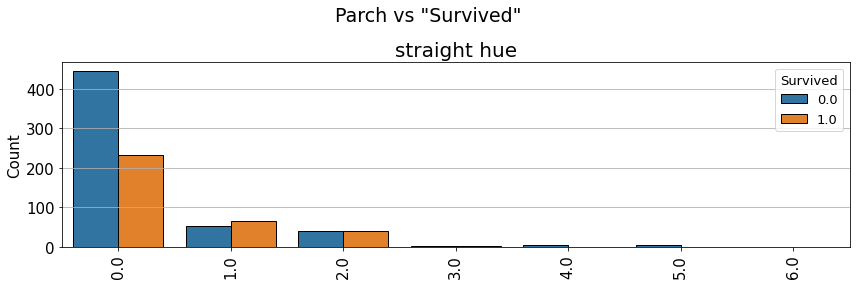

################################################################################


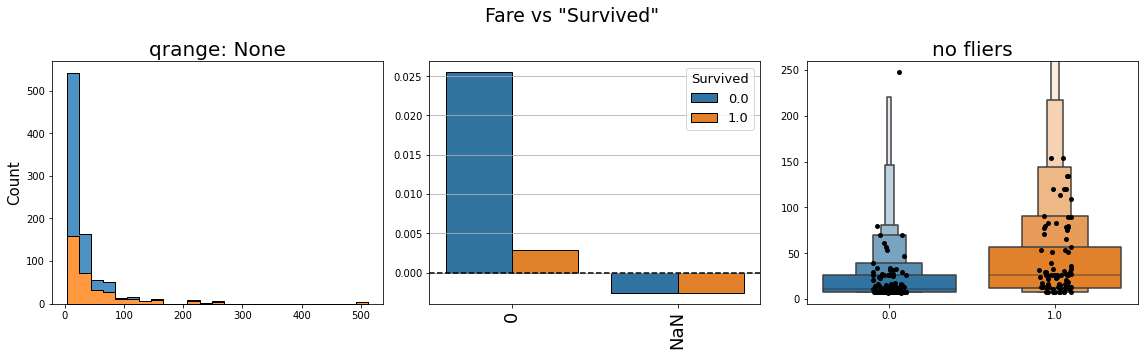

################################################################################


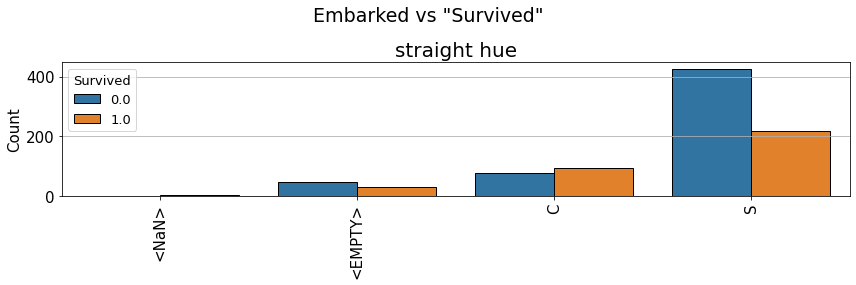

################################################################################


In [ ]:
# Это пример, не запускайте эту ячейку

# WARNING: пример не обязан соблюдать все пункты задания, но вы обязаны :)

plot_density(df, hue="Survived")

***Вопрос:*** Как вы думаете, какие проблемы с этой рисовалкой могут возникнуть при применении ее на других датасетах?

***Ответ:*** В функции есть несколько моментов, когда параметры графиков не могут быть изменены извне.

Примеры:
В отрисовке гистограммы используется фиксированное значение бинов
```python
sns.histplot(
    df.loc[index],
    x=col,
    hue=hue,
    ax=ax[0],
    bins=20,
    multiple="stack",
    stat="count",
    element="step",
    alpha=0.8,
)
ax[0].set_title(f"Distribution of {col} vs {hue}")
ax[0].yaxis.grid(True)
```
Количество примеров для отрисовки распределения также фиксировано
```python
sample_index = df.loc[index].sample(n=min(200, len(df.loc[index]))).index
sns.stripplot(df.loc[sample_index], x=col, hue=hue, ax=ax[2], alpha=0.8)
ax[2].set_title(f"200 samples for {col} vs {hue}")
ax[2].xaxis.grid(True)
```
На больших датасетах со сложными распределениями это может "поломать" графики

Также, не все датасеты имеют категориальные или числовые данные, для таких случаев функция бесполезна

Возможны ситуации, что из-за фиксированных размеров графика
```python
figsize=(15, 4)
```
При использовании функции придётся подбирать `max_cat_thr` чтобы отобразить достаточное количество категориальных колонок, при этом не жертвуя большого количества места